In [106]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import pandas as pd 
import matplotlib.pyplot as plt

In [107]:
df = pd.read_csv('income.csv')

Text(0, 0.5, 'Income')

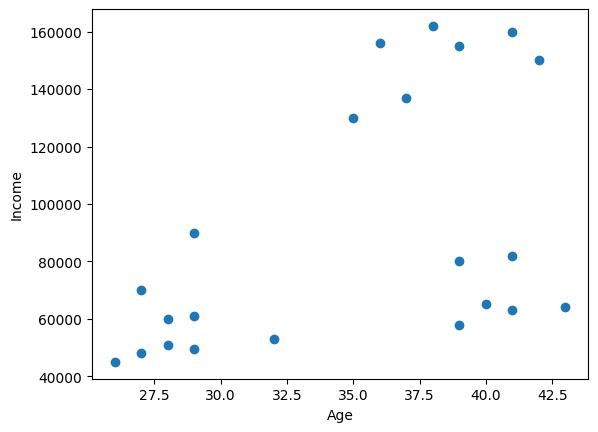

In [108]:
plt.scatter(df.Age,df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')

In [109]:
df.head(5)

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [110]:
km =KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age' , 'Income($)']])
y_predicted

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
      dtype=int32)

In [111]:
df['cluster'] = y_predicted
df.head(5)

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,2
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


In [112]:
km.cluster_centers_

array([[3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04],
       [3.63333333e+01, 8.40000000e+04]])

In [113]:
km.cluster_centers_[:,1]

array([150000.        ,  57291.66666667,  84000.        ])

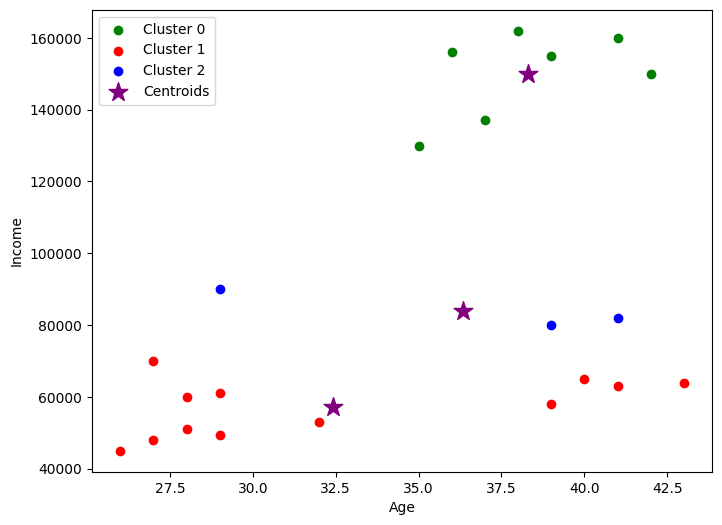

In [114]:
df1 = df[df['cluster'] == 0]
df2 = df[df['cluster'] == 1]
df3 = df[df['cluster'] == 2]
plt.figure(figsize=(8,6))

plt.scatter(df1.Age , df1['Income($)'],color='green',label='Cluster 0')
plt.scatter(df2.Age , df2['Income($)'],color='red',label='Cluster 1')
plt.scatter(df3.Age , df3['Income($)'],color='blue',label='Cluster 2')

plt.scatter(km.cluster_centers_[:,0],
            km.cluster_centers_[:,1],
            color='purple', marker='*', s=200,label='Centroids')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()

In [115]:
scaler = MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

In [116]:
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [117]:
df.head(5)

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [118]:


km_1 =KMeans(n_clusters=3)
y_predicted_1 = km_1.fit_predict(df[['Age' , 'Income($)']])
y_predicted_1

array([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [119]:
df['cluster'] = y_predicted_1
df.head(5)

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,2


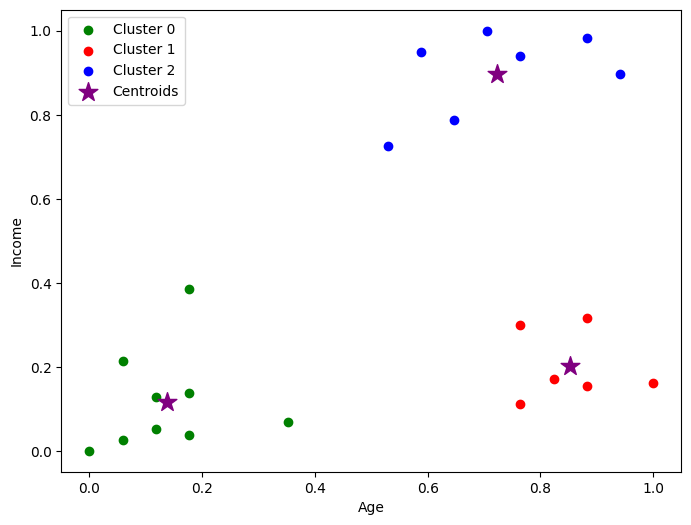

In [120]:
df1 = df[df['cluster'] == 0]
df2 = df[df['cluster'] == 1]
df3 = df[df['cluster'] == 2]
plt.figure(figsize=(8,6))

plt.scatter(df1.Age , df1['Income($)'],color='green',label='Cluster 0')
plt.scatter(df2.Age , df2['Income($)'],color='red',label='Cluster 1')
plt.scatter(df3.Age , df3['Income($)'],color='blue',label='Cluster 2')

plt.scatter(km_1.cluster_centers_[:,0],
            km_1.cluster_centers_[:,1],
            color='purple', marker='*', s=200,label='Centroids')

plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()